# Task 1 — Data Loading, Merging & Deep Exploration


In [1]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Convert date columns into datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [5]:
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [6]:
# Extract basic time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Week Number'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Day of Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

In [7]:
# Function to assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(get_season)

In [8]:
df[['Order Date',
    'Year',
    'Month',
    'Month Name',
    'Week Number',
    'Day of Week',
    'Quarter',
    'Season']].head()

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


In [9]:
missing_values = df.isnull().sum()
missing_values

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

In [10]:
missing_values[missing_values > 0]

Postal Code    11
dtype: int64

In [11]:
duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


In [12]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Month Name                  str
Week Number               int64
Day of Week                 str
Quarter                   int32
Season                      str
dtype: object

For time series analysis and forecasting, sales data must be aggregated over different time intervals. We first calculate daily total sales, which will later be used to generate weekly and monthly sales trends.

In [13]:
daily_sales = (
    df.groupby('Order Date')['Sales']
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [14]:
# Aggregate daily sales into weekly sales
weekly_sales = (
    daily_sales
    .set_index('Order Date')
    .resample('W')
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [15]:
# Aggregate daily sales into monthly sales
monthly_sales = (
    daily_sales
    .set_index('Order Date')
    .resample('ME')
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [16]:
# Calculate total sales by category
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

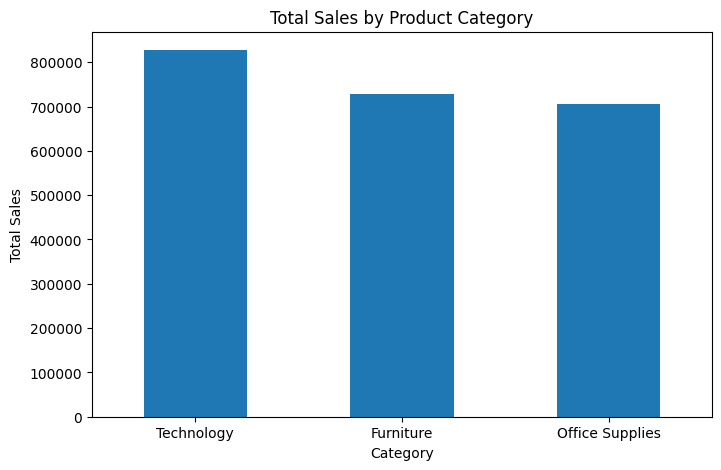

In [17]:
# Visualize total sales by category
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

Which product category generates the highest total revenue?

Based on the sales analysis, the **Technology** category is the highest revenue-generating product category. This suggests that the company should continue investing in technology products through inventory planning, marketing campaigns, and customer engagement strategies to maximize revenue growth.

In [18]:
# Year-wise sales by region
region_yearly_sales = (
    df.groupby(['Year', 'Region'])['Sales']
      .sum()
      .unstack()
)

region_yearly_sales

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


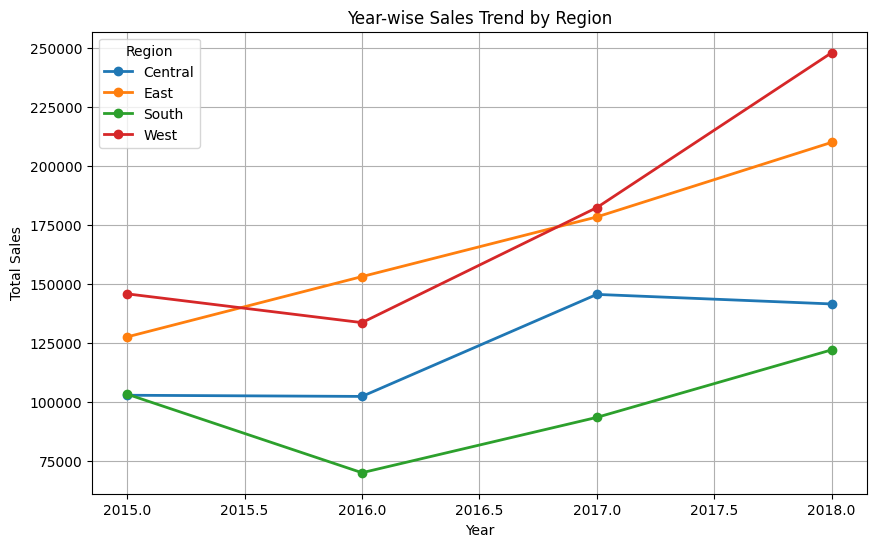

In [19]:
# Plot yearly sales by region
plt.figure(figsize=(10,6))

for region in region_yearly_sales.columns:
    plt.plot(region_yearly_sales.index,
             region_yearly_sales[region],
             marker='o',
             linewidth=2,
             label=region)

plt.title("Year-wise Sales Trend by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend(title="Region")
plt.grid(True)
plt.savefig("sales_region_category.png", dpi=300, bbox_inches="tight")
plt.show()

Which region has the most consistent sales growth over 4 years?


The **East** region has the most consistent sales growth over the four-year period. This indicates stable customer demand and sustained business performance in the region. Such consistency makes the East region a strong candidate for long-term investment, inventory planning, and future business expansion.

In [20]:
# Calculate shipping time in days
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Display first few records
df[['Order Date', 'Ship Date', 'Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [21]:
# Overall average shipping time
average_shipping_time = df['Shipping Days'].mean()

print(f"Overall Average Shipping Time: {average_shipping_time:.2f} days")

Overall Average Shipping Time: 3.96 days


In [22]:
# Average shipping time by region
region_shipping = (
    df.groupby('Region')['Shipping Days']
      .mean()
      .sort_values()
)

region_shipping

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

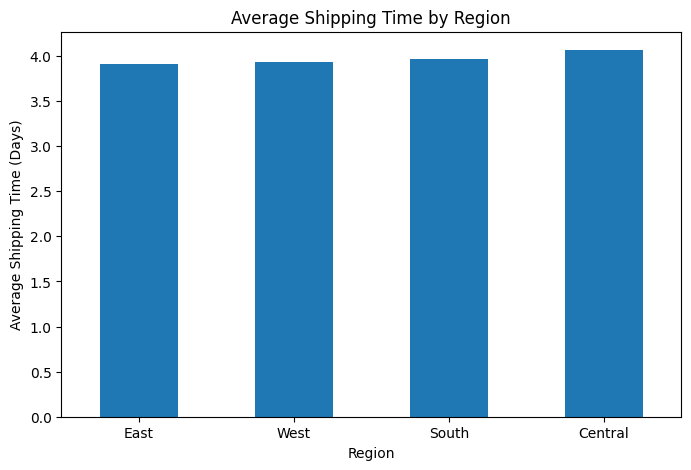

In [23]:
# Plot average shipping time by region
plt.figure(figsize=(8,5))

region_shipping.plot(kind='bar')

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Time (Days)")

plt.xticks(rotation=0)

plt.show()

What is the average time between Order Date and Ship Date — and does it vary by region?


The overall average shipping time is **3.96 days**, and regional differences are minimal. Although the **Central** region has a slightly longer delivery time, the variation is not significant. This suggests that the company maintains a consistent logistics and delivery network across all regions.

In [24]:
# Year-wise monthly sales
monthly_seasonality = (
    df.groupby(['Year', 'Month Name'])['Sales']
      .sum()
      .reset_index()
)

monthly_seasonality.head()

,Year,Month Name,Sales
0,2015,April,27906.8550
1,2015,August,27117.5365
2,2015,December,68167.0585
3,2015,February,4519.8920
4,2015,January,14205.7070


In [25]:
# Correct month order
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_seasonality['Month Name'] = pd.Categorical(
    monthly_seasonality['Month Name'],
    categories=month_order,
    ordered=True
)

monthly_seasonality = monthly_seasonality.sort_values(
    ['Year', 'Month Name']
)

monthly_seasonality.head(15)

,Year,Month Name,Sales
4,2015,January,14205.7070
3,2015,February,4519.8920
7,2015,March,55205.7970
0,2015,April,27906.8550
8,2015,May,23644.3030
6,2015,June,34322.9356
5,2015,July,33781.5430
1,2015,August,27117.5365
11,2015,September,81623.5268
10,2015,October,31453.3930


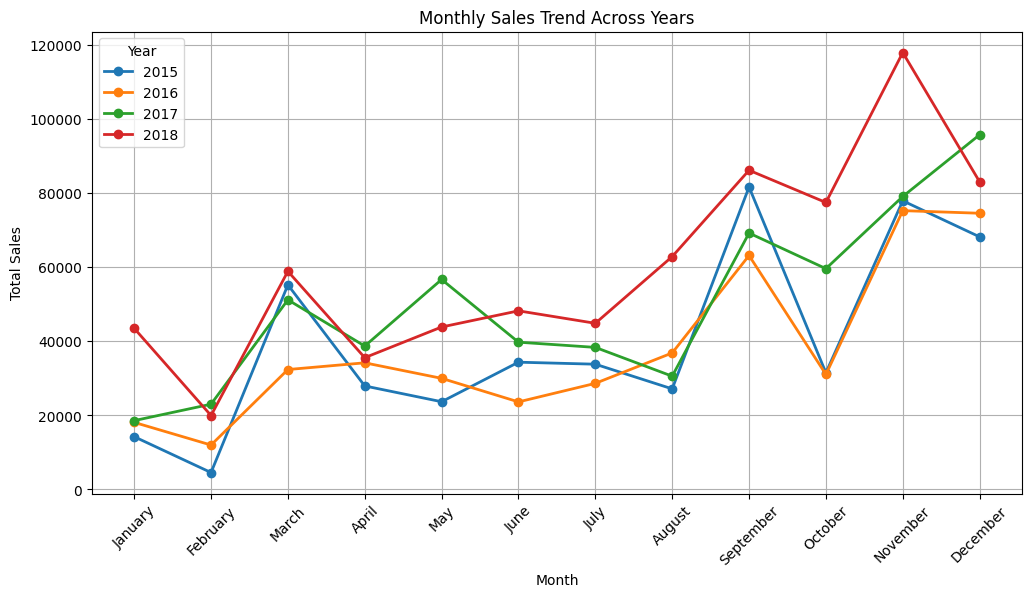

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for year in monthly_seasonality['Year'].unique():
    data = monthly_seasonality[monthly_seasonality['Year'] == year]
    
    plt.plot(
        data['Month Name'],
        data['Sales'],
        marker='o',
        linewidth=2,
        label=year
    )

plt.title("Monthly Sales Trend Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.grid(True)
plt.savefig("monthly_trend.png", dpi=300, bbox_inches="tight")

plt.show()

Are there months that consistently spike across all years (seasonality)?


Yes, there are clear seasonal spikes in sales. The strongest sales are observed during **September to December**, especially in **November**. These recurring patterns suggest that customer demand increases significantly during the festive and holiday season. Businesses should prepare higher inventory levels and supply planning during these months to meet increased demand.

# Task 2 — Time Series Analysis & Decomposition


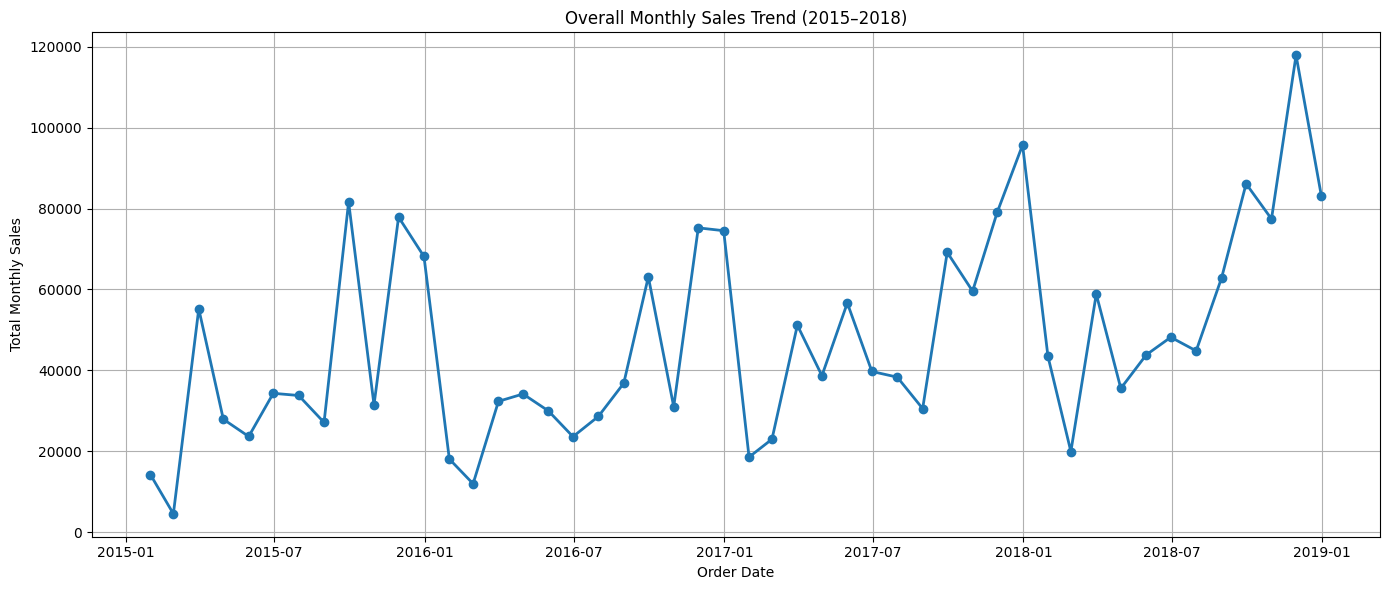

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    marker='o',
    linewidth=2
)

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Order Date")
plt.ylabel("Total Monthly Sales")

plt.grid(True)

plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=300, bbox_inches="tight")
plt.show()

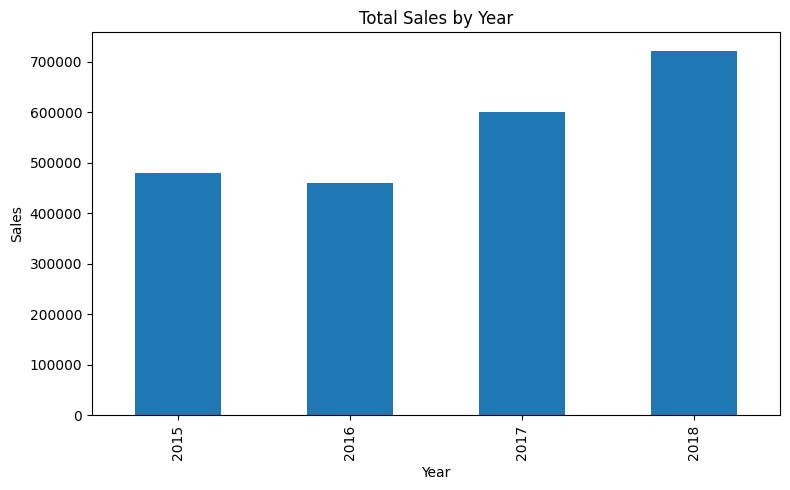

In [28]:
yearly_sales = df.groupby(df["Order Date"].dt.year)["Sales"].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(kind="bar")

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("yearly_sales.png", dpi=300)

plt.show()

In [29]:
!pip install statsmodels

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [31]:
# Set Order Date as index
ts = monthly_sales.set_index('Order Date')

# Perform time series decomposition
decomposition = seasonal_decompose(
    ts['Sales'],
    model='additive',
    period=12
)

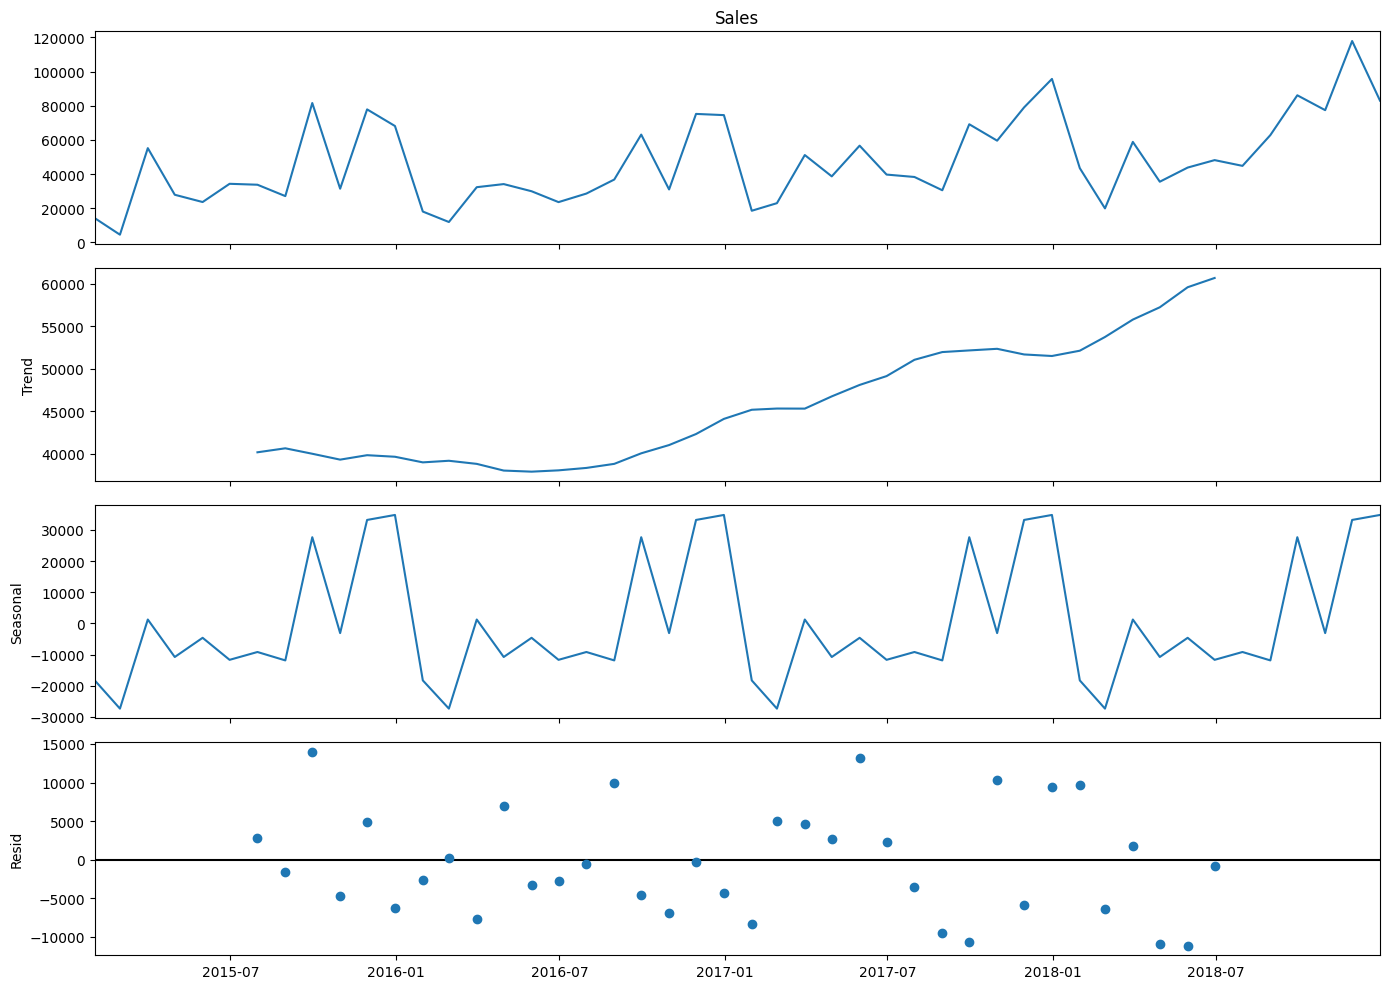

In [32]:
fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()

plt.savefig("time_series_decomposition.png", dpi=300)
plt.show()

Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?

1. The overall sales trend is increasing over the four years, showing business growth.

2. The seasonal pattern repeats every year, so the seasonality is strong.

3. The highest residual noise is seen in a few months where sales are much higher or lower than the expected trend and seasonal pattern.

4. Overall, the sales data shows both an upward trend and clear seasonal behavior.

In [33]:
from statsmodels.tsa.stattools import adfuller

# ADF Test
adf_result = adfuller(ts['Sales'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags:", adf_result[2])
print("Number of Observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Number of Lags: 0
Number of Observations: 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### ADF Test (Stationarity Check)

Stationarity means that the statistical properties of a time series, such as its mean and variance, remain stable over time. A stationary time series is more suitable for time series analysis and forecasting.

The Augmented Dickey-Fuller (ADF) Test was performed to check whether the monthly sales data is stationary.

The test returned a p-value of **0.000278**, which is less than **0.05**. This means we reject the null hypothesis and conclude that the monthly sales series is **stationary**.

Since the data is already stationary, differencing is **not required**.

### Differencing

The ADF test confirmed that the monthly sales series is already stationary (p-value < 0.05). Therefore, differencing was not applied, and re-testing was not required.

# Task 3 — Sales Forecasting using 3 Different Models


## Model 1 — SARIMA (Statistical Model)


In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [35]:
sales_ts = monthly_sales.set_index("Order Date")["Sales"]
sales_ts = sales_ts.asfreq("ME")

sales_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [36]:
# Split data into training and testing sets

train = sales_ts.iloc[:36]

test = sales_ts.iloc[36:]

<Figure size 1200x500 with 0 Axes>

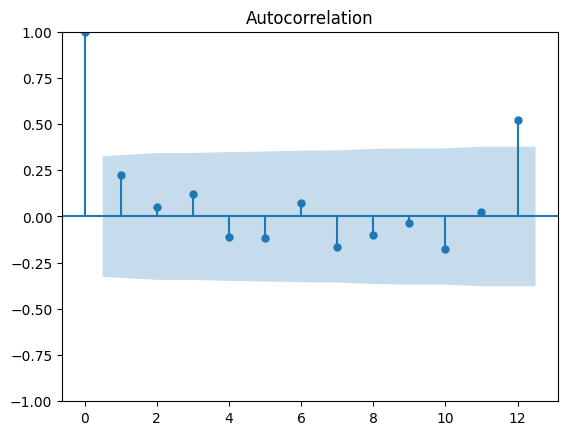

<Figure size 1200x500 with 0 Axes>

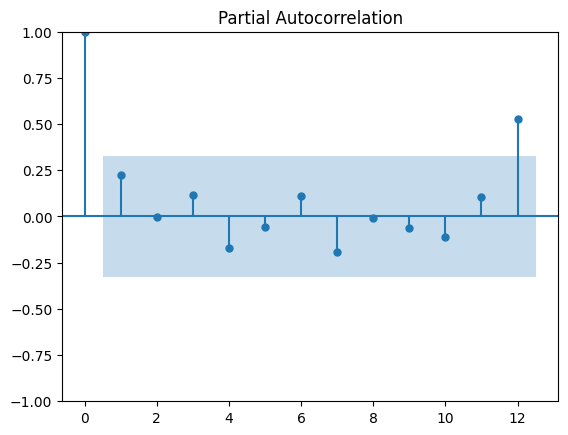

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plot_acf(train, lags=12)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(train, lags=12)
plt.show()

### SARIMA Parameter Selection
- The ACF plot showed a significant autocorrelation at **lag 1**, so the Moving Average order was selected as **q = 1**.
- The PACF plot showed a significant partial autocorrelation at **lag 1**, so the Auto-Regressive order was selected as **p = 1**.
- The Augmented Dickey-Fuller (ADF) test confirmed that the series is stationary with a **p-value of 0.000278 (< 0.05)**. Therefore, no differencing was required, and **d = 0** and **D = 0** were selected.
- Since the dataset contains **monthly sales data**, the seasonal period was set to **m = 12** to capture yearly seasonality.
- The seasonal spikes observed around **lag 12** in the ACF and PACF plots suggested including one seasonal Auto-Regressive term (**P = 1**) and one seasonal Moving Average term (**Q = 1**).

**Final SARIMA Model:** **SARIMA (1,0,1)(1,0,1,12)**

In [38]:
# Train the SARIMA model

sarima_model = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

In [39]:
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -244.084
Date:                            Mon, 13 Jul 2026   AIC                            498.168
Time:                                    00:46:49   BIC                            503.624
Sample:                                01-31-2015   HQIC                           499.454
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9781      0.289      3.379      0.001       0.411       1.545
ma.L1         -0.4279      0.655   

In [40]:
forecast = sarima_result.get_forecast(steps=len(test))

sarima_test_pred = forecast.predicted_mean

conf_int = forecast.conf_int()

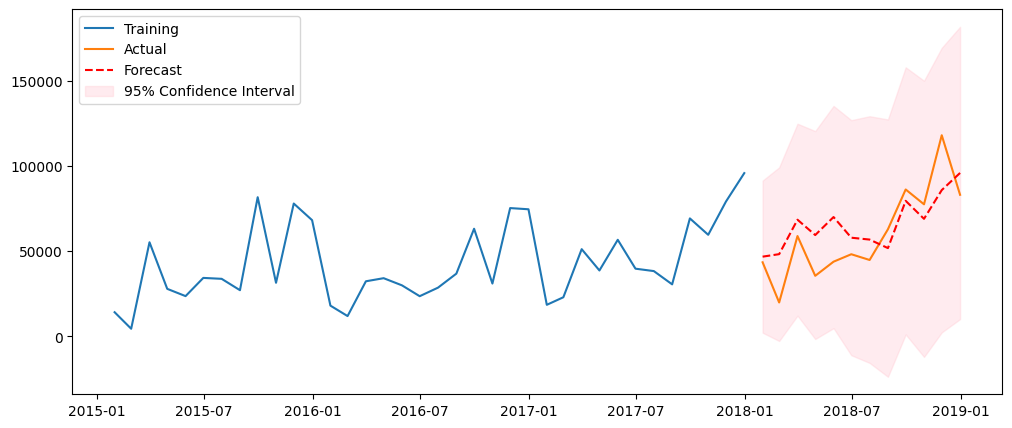

In [41]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Training")
plt.plot(test.index, test, label="Actual")

plt.plot(
    sarima_test_pred.index,
    sarima_test_pred,
    color="red",
    linestyle="--",
    label="Forecast"
)

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.legend()
plt.show()

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(test, sarima_test_pred)
rmse = np.sqrt(mean_squared_error(test, sarima_test_pred))
mape = mean_absolute_percentage_error(test, sarima_test_pred) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 15342.42
RMSE : 17875.08
MAPE : 34.90%


In [43]:
# Train SARIMA on the complete dataset

final_model = SARIMAX(
    sales_ts,
    order=(1,0,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_result = final_model.fit(disp=False)

In [44]:
# Generate forecast for next 3 months

future_forecast = final_result.get_forecast(steps=3)

future_sales = future_forecast.predicted_mean

future_conf_int = future_forecast.conf_int()

print("Next 3 Months Forecast:")
print(future_sales)

Next 3 Months Forecast:
2019-01-31    53872.247663
2019-02-28    28039.925602
2019-03-31    74457.216824
Freq: ME, Name: predicted_mean, dtype: float64


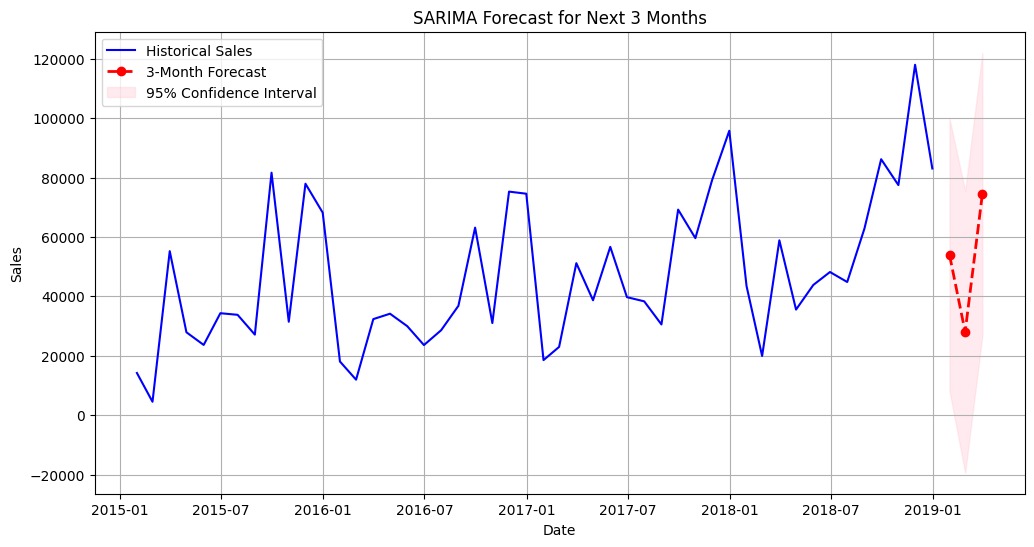

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Historical Sales
plt.plot(sales_ts, label='Historical Sales', color='blue')

# Future Forecast
plt.plot(
    future_sales.index,
    future_sales,
    color='red',
    marker='o',
    linestyle='--',
    linewidth=2,
    label='3-Month Forecast'
)

# Confidence Interval
plt.fill_between(
    future_conf_int.index,
    future_conf_int.iloc[:,0],
    future_conf_int.iloc[:,1],
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title("SARIMA Forecast for Next 3 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
fig.savefig("sarima_forecast.png", dpi=300, bbox_inches="tight")


plt.show()

## Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)


In [46]:
!pip install prophet

In [47]:
from prophet import Prophet

In [48]:
# Prepare data for Prophet

prophet_df = monthly_sales[['Order Date', 'Sales']].copy()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [49]:
# Train-Test Split for Prophet

train_prophet = prophet_df.iloc[:36]
test_prophet = prophet_df.iloc[36:]

print("Training Data:", train_prophet.shape)
print("Testing Data:", test_prophet.shape)

Training Data: (36, 2)
Testing Data: (12, 2)


In [50]:
# Create Prophet model
prophet_model = Prophet()

# Train the model
prophet_model.fit(train_prophet)

00:46:56 - cmdstanpy - INFO - Chain [1] start processing
00:46:57 - cmdstanpy - INFO - Chain [1] done processing


In [51]:
# Create future dataframe for test period
future = prophet_model.make_future_dataframe(periods=12, freq='ME')

future.tail()

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [52]:
# Predict future values
forecast = prophet_model.predict(future)

# Display predicted values
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,40311.295541,33515.555528,47898.845218
44,2018-09-30,86532.357728,79432.656912,94369.603300
45,2018-10-31,50900.787680,43342.243458,57887.408267
46,2018-11-30,89710.818828,82872.708541,96702.343216
47,2018-12-31,89211.295214,82422.312721,96446.671145


In [53]:
# Extract predictions for the test period
prophet_test_pred = forecast.iloc[-12:][['ds', 'yhat']]

prophet_test_pred.head()

,ds,yhat
36,2018-01-31,27276.511874
37,2018-02-28,22184.016848
38,2018-03-31,62221.876560
39,2018-04-30,43283.744582
40,2018-05-31,45039.201947


In [54]:
# Reset index of test data
test_actual = test_prophet.reset_index(drop=True)

# Reset index of predicted data
prophet_pred = prophet_test_pred.reset_index(drop=True)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Date': test_actual['ds'],
    'Actual Sales': test_actual['y'],
    'Predicted Sales': prophet_pred['yhat']
})

comparison.head()

,Date,Actual Sales,Predicted Sales
0,2018-01-31,43476.4740,27276.511874
1,2018-02-28,19920.9974,22184.016848
2,2018-03-31,58863.4128,62221.876560
3,2018-04-30,35541.9101,43283.744582
4,2018-05-31,43825.9822,45039.201947


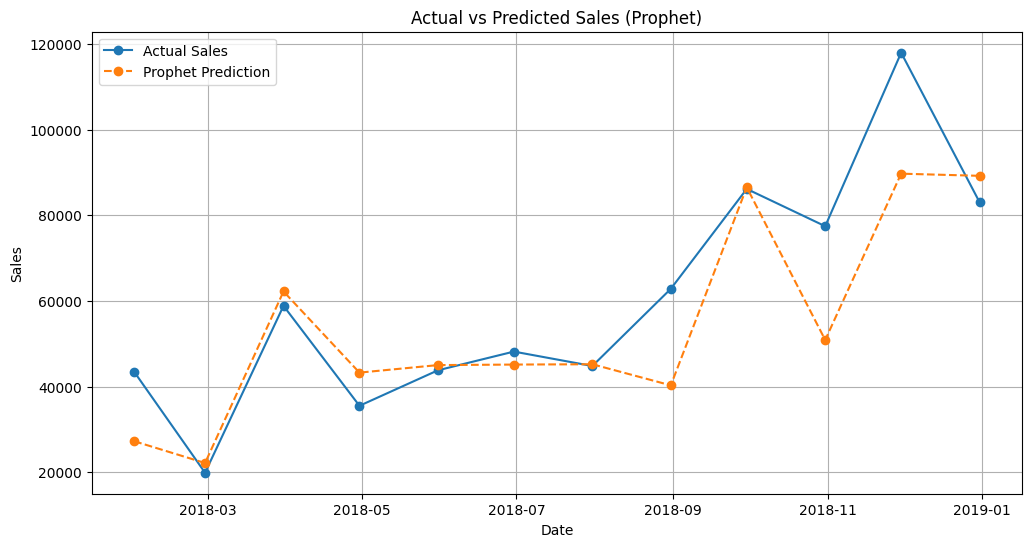

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(comparison['Date'],
         comparison['Actual Sales'],
         marker='o',
         label='Actual Sales')

plt.plot(comparison['Date'],
         comparison['Predicted Sales'],
         marker='o',
         linestyle='--',
         label='Prophet Prediction')

plt.title("Actual vs Predicted Sales (Prophet)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(comparison['Actual Sales'],
                          comparison['Predicted Sales'])

rmse = np.sqrt(mean_squared_error(comparison['Actual Sales'],
                                  comparison['Predicted Sales']))

mape = np.mean(
    np.abs((comparison['Actual Sales'] - comparison['Predicted Sales']) /
           comparison['Actual Sales'])
) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 9839.84
RMSE : 14133.08
MAPE : 15.67%


In [57]:
# Train Prophet on the complete dataset

final_prophet = Prophet()

final_prophet.fit(prophet_df)

00:46:58 - cmdstanpy - INFO - Chain [1] start processing
00:46:58 - cmdstanpy - INFO - Chain [1] done processing


In [58]:
# Create future dataframe for next 3 months

future_3 = final_prophet.make_future_dataframe(periods=3, freq='ME')

future_3.tail()

,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [59]:
# Predict next 3 months
forecast_3 = final_prophet.predict(future_3)

# Display only the next 3 months forecast
forecast_3[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532203,33976.442979,52844.843572
49,2019-02-28,31248.159923,21784.003887,40675.211023
50,2019-03-31,81267.007773,71438.130015,90537.592574


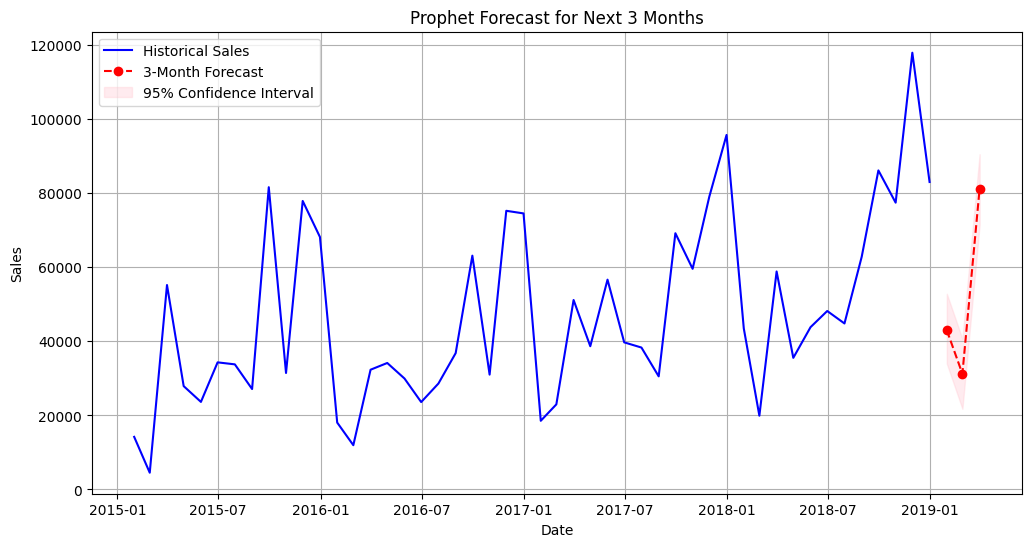

In [60]:
plt.figure(figsize=(12,6))

# Historical Sales
plt.plot(prophet_df['ds'],
         prophet_df['y'],
         color='blue',
         label='Historical Sales')

# Forecast
plt.plot(forecast_3['ds'].tail(3),
         forecast_3['yhat'].tail(3),
         marker='o',
         linestyle='--',
         color='red',
         label='3-Month Forecast')

# Confidence Interval
plt.fill_between(
    forecast_3['ds'].tail(3),
    forecast_3['yhat_lower'].tail(3),
    forecast_3['yhat_upper'].tail(3),
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title("Prophet Forecast for Next 3 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
fig.savefig("prophet_forecast.png", dpi=300, bbox_inches="tight")

plt.show()

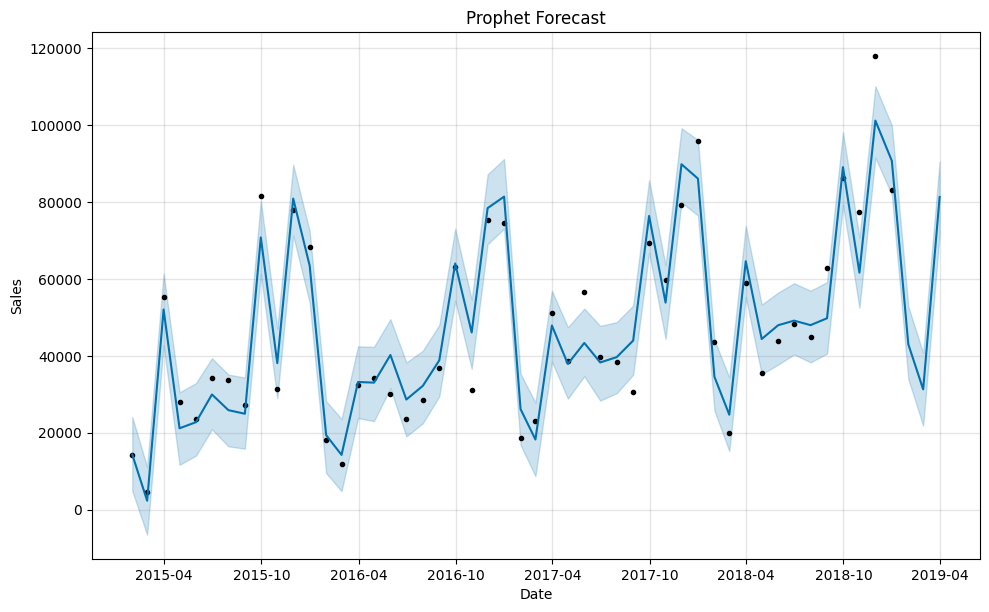

In [61]:
# Plot the complete forecast
fig1 = final_prophet.plot(forecast_3)

plt.title("Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

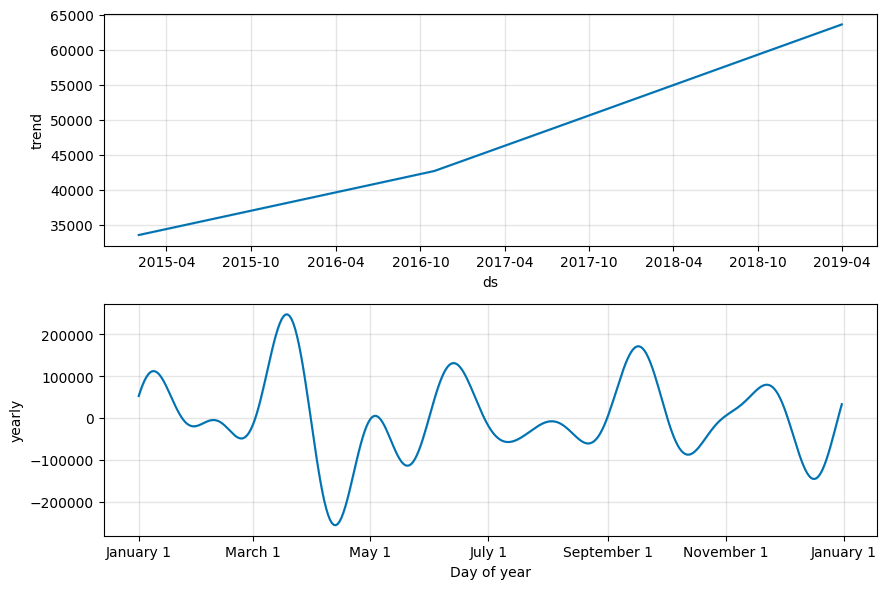

In [62]:
# Plot trend and seasonality components
fig2 = final_prophet.plot_components(forecast_3)

plt.show()

### Weekly Seasonality Interpretation

Weekly seasonality was not generated because the dataset contains monthly sales data instead of daily observations. Since there are no day-wise records, Prophet cannot detect or estimate weekly sales patterns.

## Model 3 — XGBoost for Time Series (ML-based Approach)


In [63]:
!pip install xgboost

In [64]:
# Create a copy of monthly sales data
xgb_df = monthly_sales.copy()

# Keep only required columns
xgb_df = xgb_df[['Order Date', 'Sales']]

# Create lag features
xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)

xgb_df.head(10)

,Order Date,Sales,Lag_1,Lag_2,Lag_3
0,2015-01-31,14205.7070,NaN,NaN,NaN
1,2015-02-28,4519.8920,14205.7070,NaN,NaN
2,2015-03-31,55205.7970,4519.8920,14205.7070,NaN
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.7070
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.8920
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.7970
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.8550
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.3030
8,2015-09-30,81623.5268,27117.5365,33781.5430,34322.9356
9,2015-10-31,31453.3930,81623.5268,27117.5365,33781.5430


In [65]:
# Create 3-month rolling mean feature
xgb_df['Rolling_Mean_3'] = xgb_df['Sales'].rolling(window=3).mean()

xgb_df.head(10)

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
0,2015-01-31,14205.7070,NaN,NaN,NaN,NaN
1,2015-02-28,4519.8920,14205.7070,NaN,NaN,NaN
2,2015-03-31,55205.7970,4519.8920,14205.7070,NaN,24643.798667
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.7070,29210.848000
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.8920,35585.651667
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.7970,28624.697867
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.8550,30582.927200
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.3030,31740.671700
8,2015-09-30,81623.5268,27117.5365,33781.5430,34322.9356,47507.535433
9,2015-10-31,31453.3930,81623.5268,27117.5365,33781.5430,46731.485433


In [66]:
# Extract Month and Quarter
xgb_df['Month'] = xgb_df['Order Date'].dt.month
xgb_df['Quarter'] = xgb_df['Order Date'].dt.quarter

# Create Season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 1   # Winter
    elif month in [3, 4, 5]:
        return 2   # Summer
    elif month in [6, 7, 8]:
        return 3   # Monsoon
    else:
        return 4   # Autumn

xgb_df['Season'] = xgb_df['Month'].apply(get_season)

xgb_df.head(10)

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-01-31,14205.7070,NaN,NaN,NaN,NaN,1,1,1
1,2015-02-28,4519.8920,14205.7070,NaN,NaN,NaN,2,1,1
2,2015-03-31,55205.7970,4519.8920,14205.7070,NaN,24643.798667,3,1,2
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.7070,29210.848000,4,2,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.8920,35585.651667,5,2,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.7970,28624.697867,6,2,3
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.8550,30582.927200,7,3,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.3030,31740.671700,8,3,3
8,2015-09-30,81623.5268,27117.5365,33781.5430,34322.9356,47507.535433,9,3,4
9,2015-10-31,31453.3930,81623.5268,27117.5365,33781.5430,46731.485433,10,4,4


In [67]:
# Remove rows with missing values
xgb_df = xgb_df.dropna().reset_index(drop=True)

# Check the dataset
xgb_df.head()

print("Dataset Shape:", xgb_df.shape)

Dataset Shape: (45, 9)


In [68]:
xgb_df[['Order Date']].tail(15)

,Order Date
30,2017-10-31
31,2017-11-30
32,2017-12-31
33,2018-01-31
34,2018-02-28
35,2018-03-31
36,2018-04-30
37,2018-05-31
38,2018-06-30
39,2018-07-31


In [69]:
# Split data into training and testing sets

train_xgb = xgb_df[xgb_df['Order Date'] < '2018-01-01']
test_xgb = xgb_df[xgb_df['Order Date'] >= '2018-01-01']

print("Training Data Shape:", train_xgb.shape)
print("Testing Data Shape:", test_xgb.shape)

Training Data Shape: (33, 9)
Testing Data Shape: (12, 9)


In [70]:
# Separate Features and Target

X_train = train_xgb.drop(['Order Date', 'Sales'], axis=1)
y_train = train_xgb['Sales']

X_test = test_xgb.drop(['Order Date', 'Sales'], axis=1)
y_test = test_xgb['Sales']

In [71]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train.head()

X_train Shape: (33, 7)
X_test Shape: (12, 7)


,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
1,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
3,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
4,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [72]:
from xgboost import XGBRegressor

In [73]:
# Create XGBoost model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [74]:
# Predict sales on test data

xgb_pred = xgb_model.predict(X_test)

# Display first 5 predictions
print(xgb_pred[:5])

[34098.83  23274.438 42451.145 40184.266 41654.05 ]


In [75]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape = mean_absolute_percentage_error(y_test, xgb_pred)

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape * 100, 2), "%")

MAE : 9397.61
RMSE : 12725.68
MAPE : 15.35 %


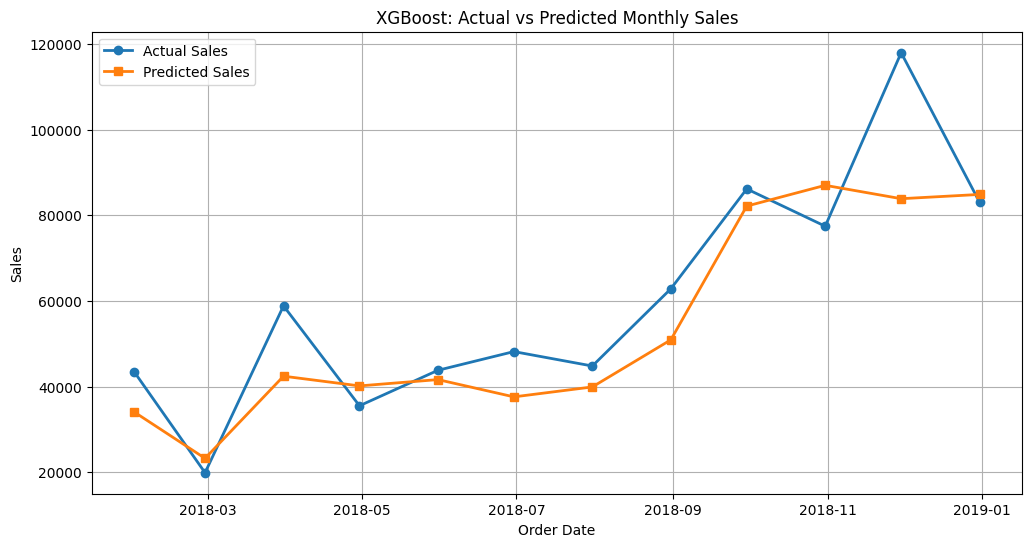

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test_xgb['Order Date'], y_test,
         marker='o', linewidth=2,
         label='Actual Sales')

plt.plot(test_xgb['Order Date'], xgb_pred,
         marker='s', linewidth=2,
         label='Predicted Sales')

plt.title("XGBoost: Actual vs Predicted Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [77]:
# Last available row
xgb_df.tail(1)


,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
44,2018-12-31,83030.3888,117938.155,77448.1312,86152.888,92805.558333,12,4,1


In [78]:
# Last row of dataset
last_row = xgb_df.iloc[-1]

# Features for January 2019
future_features = pd.DataFrame({

    'Lag_1': [last_row['Sales']],
    'Lag_2': [last_row['Lag_1']],
    'Lag_3': [last_row['Lag_2']],

    'Rolling_Mean_3': [(
        last_row['Sales'] +
        last_row['Lag_1'] +
        last_row['Lag_2']
    ) / 3],

    'Month': [1],
    'Quarter': [1],
    'Season': [1]

})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,83030.3888,117938.155,77448.1312,92805.558333,1,1,1


In [79]:
# Predict January 2019 Sales
jan_pred = xgb_model.predict(future_features)

print("January 2019 Forecast:", round(jan_pred[0], 2))

January 2019 Forecast: 37130.08


In [80]:
# Features for February 2019
future_features_feb = pd.DataFrame({

    'Lag_1': [jan_pred[0]],            # January prediction
    'Lag_2': [last_row['Sales']],      # December actual
    'Lag_3': [last_row['Lag_1']],      # November actual

    'Rolling_Mean_3': [(
        jan_pred[0] +
        last_row['Sales'] +
        last_row['Lag_1']
    ) / 3],

    'Month': [2],
    'Quarter': [1],
    'Season': [1]

})

future_features_feb

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,37130.074219,83030.3888,117938.155,79366.206006,2,1,1


In [81]:
# Predict February 2019 Sales
feb_pred = xgb_model.predict(future_features_feb)

print("February 2019 Forecast:", round(feb_pred[0], 2))

February 2019 Forecast: 28415.0


In [82]:
# Features for March 2019
future_features_mar = pd.DataFrame({

    'Lag_1': [feb_pred[0]],          # February prediction
    'Lag_2': [jan_pred[0]],          # January prediction
    'Lag_3': [last_row['Sales']],    # December actual

    'Rolling_Mean_3': [(
        feb_pred[0] +
        jan_pred[0] +
        last_row['Sales']
    ) / 3],

    'Month': [3],
    'Quarter': [1],
    'Season': [2]

})

future_features_mar

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,28414.998047,37130.074219,83030.3888,49525.153038,3,1,2


In [83]:
# Predict March 2019 Sales
mar_pred = xgb_model.predict(future_features_mar)

print("March 2019 Forecast:", round(mar_pred[0], 2))

March 2019 Forecast: 55793.52


In [84]:
forecast_df = pd.DataFrame({
    'Month': ['2019-01-31', '2019-02-28', '2019-03-31'],
    'Predicted Sales': [
        round(jan_pred[0], 2),
        round(feb_pred[0], 2),
        round(mar_pred[0], 2)
    ]
})

forecast_df

,Month,Predicted Sales
0,2019-01-31,37130.078125
1,2019-02-28,28415.000000
2,2019-03-31,55793.519531


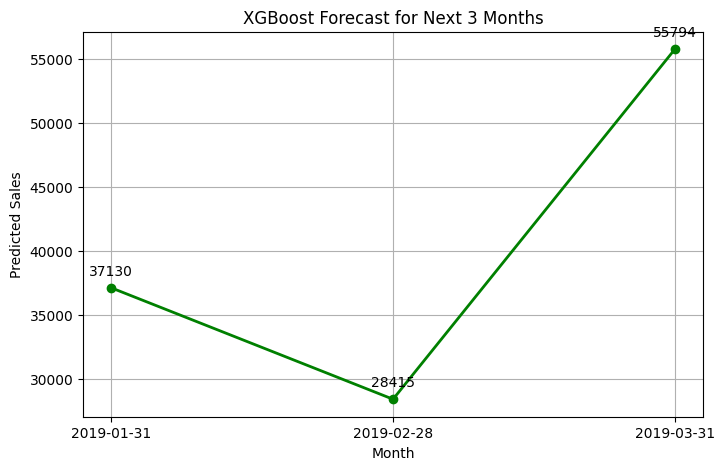

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    forecast_df['Month'],
    forecast_df['Predicted Sales'],
    marker='o',
    linewidth=2,
    color='green'
)

plt.title("XGBoost Forecast for Next 3 Months")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.grid(True)

for i, value in enumerate(forecast_df['Predicted Sales']):
    plt.text(i, value+1000, f"{value:.0f}", ha='center')
    fig.savefig("xgboost_forecast.png", dpi=300, bbox_inches="tight")

plt.show()

In [86]:
comparison_table = pd.DataFrame({

    'Model': ['SARIMA', 'Prophet', 'XGBoost'],

    'MAE': [
        15342.42,
        9839.84,
        9397.61
    ],

    'RMSE': [
        17875.08,
        14133.08,
        12725.68
    ],

    'MAPE (%)': [
        34.90,
        15.67,
        15.35
    ],

    'Forecast Month 1\n(Jan-2019)': [
        53872.25,
        42990.53,
        37130.08
    ],

    'Forecast Month 2\n(Feb-2019)': [
        28039.93,
        31248.16,
        28415.00
    ],

    'Forecast Month 3\n(Mar-2019)': [
        74457.22,
        81267.01,
        55793.52
    ]

})

comparison_table

,Model,MAE,RMSE,MAPE (%),Forecast Month 1\n(Jan-2019),Forecast Month 2\n(Feb-2019),Forecast Month 3\n(Mar-2019)
0,SARIMA,15342.42,17875.08,34.90,53872.25,28039.93,74457.22
1,Prophet,9839.84,14133.08,15.67,42990.53,31248.16,81267.01
2,XGBoost,9397.61,12725.68,15.35,37130.08,28415.00,55793.52


### Recommendation

Among the three forecasting models, XGBoost achieved the lowest MAE (9397.61), RMSE (12725.68), and MAPE (15.35%). Therefore, XGBoost is recommended for production use because it provides the highest forecasting accuracy on the test dataset.

# Task 4 — Product Category & Region Level Forecasting

In [87]:
# Furniture monthly sales
furniture_monthly = (
    df[df['Category'] == 'Furniture']
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

furniture_monthly.head()

,Order Date,Sales
0,2015-01-31,6217.277
1,2015-02-28,1839.658
2,2015-03-31,14243.368
3,2015-04-30,7944.837
4,2015-05-31,6912.787


In [88]:
print(furniture_monthly.shape)
furniture_monthly.tail()

(48, 2)


,Order Date,Sales
43,2018-08-31,15419.1220
44,2018-09-30,28516.7060
45,2018-10-31,21884.0682
46,2018-11-30,37056.7150
47,2018-12-31,31407.4668


In [89]:
furniture_xgb = furniture_monthly.copy()

furniture_xgb.head()

,Order Date,Sales
0,2015-01-31,6217.277
1,2015-02-28,1839.658
2,2015-03-31,14243.368
3,2015-04-30,7944.837
4,2015-05-31,6912.787


In [90]:
# Create lag features
furniture_xgb['Lag_1'] = furniture_xgb['Sales'].shift(1)
furniture_xgb['Lag_2'] = furniture_xgb['Sales'].shift(2)
furniture_xgb['Lag_3'] = furniture_xgb['Sales'].shift(3)

# Check
furniture_xgb.head(6)

,Order Date,Sales,Lag_1,Lag_2,Lag_3
0,2015-01-31,6217.2770,NaN,NaN,NaN
1,2015-02-28,1839.6580,6217.277,NaN,NaN
2,2015-03-31,14243.3680,1839.658,6217.277,NaN
3,2015-04-30,7944.8370,14243.368,1839.658,6217.277
4,2015-05-31,6912.7870,7944.837,14243.368,1839.658
5,2015-06-30,13144.5816,6912.787,7944.837,14243.368


In [91]:
# Create 3-month Rolling Mean
furniture_xgb['Rolling_Mean_3'] = furniture_xgb['Sales'].rolling(window=3).mean()

# Check
furniture_xgb.head(6)

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
0,2015-01-31,6217.2770,NaN,NaN,NaN,NaN
1,2015-02-28,1839.6580,6217.277,NaN,NaN,NaN
2,2015-03-31,14243.3680,1839.658,6217.277,NaN,7433.434333
3,2015-04-30,7944.8370,14243.368,1839.658,6217.277,8009.287667
4,2015-05-31,6912.7870,7944.837,14243.368,1839.658,9700.330667
5,2015-06-30,13144.5816,6912.787,7944.837,14243.368,9334.068533


In [92]:
# Month and Quarter
furniture_xgb['Month'] = furniture_xgb['Order Date'].dt.month
furniture_xgb['Quarter'] = furniture_xgb['Order Date'].dt.quarter

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return 1   # Winter
    elif month in [3, 4, 5]:
        return 2   # Summer
    elif month in [6, 7, 8]:
        return 3   # Monsoon
    else:
        return 4   # Autumn

furniture_xgb['Season'] = furniture_xgb['Month'].apply(get_season)

# Check
furniture_xgb.head(6)

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-01-31,6217.2770,NaN,NaN,NaN,NaN,1,1,1
1,2015-02-28,1839.6580,6217.277,NaN,NaN,NaN,2,1,1
2,2015-03-31,14243.3680,1839.658,6217.277,NaN,7433.434333,3,1,2
3,2015-04-30,7944.8370,14243.368,1839.658,6217.277,8009.287667,4,2,2
4,2015-05-31,6912.7870,7944.837,14243.368,1839.658,9700.330667,5,2,2
5,2015-06-30,13144.5816,6912.787,7944.837,14243.368,9334.068533,6,2,3


In [93]:
# Remove rows with missing values
furniture_xgb = furniture_xgb.dropna().reset_index(drop=True)

# Check dataset
print("Dataset Shape:", furniture_xgb.shape)
furniture_xgb.head()

Dataset Shape: (45, 9)


,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,7944.8370,14243.3680,1839.6580,6217.277,8009.287667,4,2,2
1,2015-05-31,6912.7870,7944.8370,14243.3680,1839.658,9700.330667,5,2,2
2,2015-06-30,13144.5816,6912.7870,7944.8370,14243.368,9334.068533,6,2,3
3,2015-07-31,10821.0510,13144.5816,6912.7870,7944.837,10292.806533,7,3,3
4,2015-08-31,7125.2105,10821.0510,13144.5816,6912.787,10363.614367,8,3,3


In [94]:
X_full = furniture_xgb.drop(columns=['Order Date', 'Sales'])
y_full = furniture_xgb['Sales']

In [95]:
from xgboost import XGBRegressor

furniture_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

furniture_model.fit(X_full, y_full)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [96]:
# Last row of Furniture dataset
last_row = furniture_xgb.iloc[-1]

# Features for January 2019
future_features = pd.DataFrame({

    'Lag_1': [last_row['Sales']],
    'Lag_2': [last_row['Lag_1']],
    'Lag_3': [last_row['Lag_2']],

    'Rolling_Mean_3': [(
        last_row['Sales'] +
        last_row['Lag_1'] +
        last_row['Lag_2']
    ) / 3],

    'Month': [1],
    'Quarter': [1],
    'Season': [1]

})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,31407.4668,37056.715,21884.0682,30116.083333,1,1,1


In [97]:
# Predict January 2019 Furniture Sales
jan_pred = furniture_model.predict(future_features)

print("January 2019 Furniture Forecast:", round(jan_pred[0], 2))

January 2019 Furniture Forecast: 9716.0


In [98]:
# Features for February 2019
future_features = pd.DataFrame({
    'Lag_1': [jan_pred[0]],
    'Lag_2': [last_row['Sales']],
    'Lag_3': [last_row['Lag_1']],
    'Rolling_Mean_3': [(
        jan_pred[0] +
        last_row['Sales'] +
        last_row['Lag_1']
    ) / 3],
    'Month': [2],
    'Quarter': [1],
    'Season': [1]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,9716.00293,31407.4668,37056.715,26060.061577,2,1,1


In [99]:
# Predict February 2019 Furniture Sales
feb_pred = furniture_model.predict(future_features)

print("February 2019 Furniture Forecast:", round(feb_pred[0], 2))

February 2019 Furniture Forecast: 6214.69


In [100]:
# Features for March 2019
future_features = pd.DataFrame({
    'Lag_1': [feb_pred[0]],
    'Lag_2': [jan_pred[0]],
    'Lag_3': [last_row['Sales']],
    'Rolling_Mean_3': [(
        feb_pred[0] +
        jan_pred[0] +
        last_row['Sales']
    ) / 3],
    'Month': [3],
    'Quarter': [1],
    'Season': [2]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,6214.686523,9716.00293,31407.4668,15779.385418,3,1,2


In [101]:
# Predict March 2019 Furniture Sales
mar_pred = furniture_model.predict(future_features)

print("March 2019 Furniture Forecast:", round(mar_pred[0], 2))

March 2019 Furniture Forecast: 16723.81


In [102]:
furniture_forecast = pd.DataFrame({
    'Month': ['2019-01', '2019-02', '2019-03'],
    'Furniture': [
        round(jan_pred[0], 2),
        round(feb_pred[0], 2),
        round(mar_pred[0], 2)
    ]
})

furniture_forecast

,Month,Furniture
0,2019-01,9716.000000
1,2019-02,6214.689941
2,2019-03,16723.810547


In [103]:
technology_monthly = (
    df[df['Category'] == 'Technology']
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

technology_monthly.head()

,Order Date,Sales
0,2015-01-31,3143.290
1,2015-02-28,1608.510
2,2015-03-31,32359.974
3,2015-04-30,8973.144
4,2015-05-31,9599.876


In [104]:
technology_xgb = technology_monthly.copy()

# Lag Features
technology_xgb['Lag_1'] = technology_xgb['Sales'].shift(1)
technology_xgb['Lag_2'] = technology_xgb['Sales'].shift(2)
technology_xgb['Lag_3'] = technology_xgb['Sales'].shift(3)

# Rolling Mean
technology_xgb['Rolling_Mean_3'] = technology_xgb['Sales'].rolling(3).mean()

# Time Features
technology_xgb['Month'] = technology_xgb['Order Date'].dt.month
technology_xgb['Quarter'] = technology_xgb['Order Date'].dt.quarter

# Season
technology_xgb['Season'] = technology_xgb['Month'].apply(get_season)

# Remove Missing Values
technology_xgb.dropna(inplace=True)

technology_xgb.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,8973.144,32359.974,1608.510,3143.290,14313.876000,4,2,2
4,2015-05-31,9599.876,8973.144,32359.974,1608.510,16977.664667,5,2,2
5,2015-06-30,8435.965,9599.876,8973.144,32359.974,9002.995000,6,2,3
6,2015-07-31,7839.284,8435.965,9599.876,8973.144,8625.041667,7,3,3
7,2015-08-31,8937.050,7839.284,8435.965,9599.876,8404.099667,8,3,3


In [105]:
# Features and Target
X_full = technology_xgb.drop(columns=['Order Date', 'Sales'])
y_full = technology_xgb['Sales']

# Train Model
technology_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

technology_model.fit(X_full, y_full)

print("Technology model trained successfully.")

Technology model trained successfully.


In [106]:
# Last row of Technology dataset
last_row = technology_xgb.iloc[-1]

# Features for January 2019
future_features = pd.DataFrame({
    'Lag_1': [last_row['Sales']],
    'Lag_2': [last_row['Lag_1']],
    'Lag_3': [last_row['Lag_2']],
    'Rolling_Mean_3': [(
        last_row['Sales'] +
        last_row['Lag_1'] +
        last_row['Lag_2']
    ) / 3],
    'Month': [1],
    'Quarter': [1],
    'Season': [1]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,21984.91,49409.103,32855.663,34749.892,1,1,1


In [107]:
# Predict January 2019 Technology Sales
jan_pred = technology_model.predict(future_features)

print("January 2019 Technology Forecast:", round(jan_pred[0], 2))

January 2019 Technology Forecast: 20370.97


In [108]:
future_features = pd.DataFrame({
    'Lag_1': [jan_pred[0]],
    'Lag_2': [last_row['Sales']],
    'Lag_3': [last_row['Lag_1']],
    'Rolling_Mean_3': [(
        jan_pred[0] +
        last_row['Sales'] +
        last_row['Lag_1']
    ) / 3],
    'Month': [2],
    'Quarter': [1],
    'Season': [1]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,20370.966797,21984.91,49409.103,30588.326599,2,1,1


In [109]:
# Predict February 2019 Technology Sales
feb_pred = technology_model.predict(future_features)

print("February 2019 Technology Forecast:", round(feb_pred[0], 2))

February 2019 Technology Forecast: 24370.32


In [110]:
future_features = pd.DataFrame({
    'Lag_1': [feb_pred[0]],
    'Lag_2': [jan_pred[0]],
    'Lag_3': [last_row['Sales']],
    'Rolling_Mean_3': [(
        feb_pred[0] +
        jan_pred[0] +
        last_row['Sales']
    ) / 3],
    'Month': [3],
    'Quarter': [1],
    'Season': [2]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,24370.316406,20370.966797,21984.91,22242.06375,3,1,2


In [111]:
# Predict March 2019 Technology Sales
mar_pred = technology_model.predict(future_features)

print("March 2019 Technology Forecast:", round(mar_pred[0], 2))

March 2019 Technology Forecast: 30328.62


In [112]:
technology_forecast = pd.DataFrame({
    'Month': ['2019-01', '2019-02', '2019-03'],
    'Technology': [
        round(jan_pred[0], 2),
        round(feb_pred[0], 2),
        round(mar_pred[0], 2)
    ]
})

technology_forecast

,Month,Technology
0,2019-01,20370.970703
1,2019-02,24370.320312
2,2019-03,30328.619141


In [113]:
office_monthly = (
    df[df['Category'] == 'Office Supplies']
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

office_monthly.head()

,Order Date,Sales
0,2015-01-31,4845.140
1,2015-02-28,1071.724
2,2015-03-31,8602.455
3,2015-04-30,10988.874
4,2015-05-31,7131.640


In [114]:
office_xgb = office_monthly.copy()

# Lag Features
office_xgb['Lag_1'] = office_xgb['Sales'].shift(1)
office_xgb['Lag_2'] = office_xgb['Sales'].shift(2)
office_xgb['Lag_3'] = office_xgb['Sales'].shift(3)

# Rolling Mean
office_xgb['Rolling_Mean_3'] = office_xgb['Sales'].rolling(3).mean()

# Time Features
office_xgb['Month'] = office_xgb['Order Date'].dt.month
office_xgb['Quarter'] = office_xgb['Order Date'].dt.quarter

# Season
office_xgb['Season'] = office_xgb['Month'].apply(get_season)

# Remove Missing Values
office_xgb.dropna(inplace=True)

office_xgb.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,10988.874,8602.455,1071.724,4845.140,6887.684333,4,2,2
4,2015-05-31,7131.640,10988.874,8602.455,1071.724,8907.656333,5,2,2
5,2015-06-30,12742.389,7131.640,10988.874,8602.455,10287.634333,6,2,3
6,2015-07-31,15121.208,12742.389,7131.640,10988.874,11665.079000,7,3,3
7,2015-08-31,11055.276,15121.208,12742.389,7131.640,12972.957667,8,3,3


In [115]:
# Features and Target
X_full = office_xgb.drop(columns=['Order Date', 'Sales'])
y_full = office_xgb['Sales']

# Train Model
office_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

office_model.fit(X_full, y_full)

print("Office Supplies model trained successfully.")

Office Supplies model trained successfully.


In [116]:
# Last row of Office Supplies dataset
last_row = office_xgb.iloc[-1]

# Features for January 2019
future_features = pd.DataFrame({
    'Lag_1': [last_row['Sales']],
    'Lag_2': [last_row['Lag_1']],
    'Lag_3': [last_row['Lag_2']],
    'Rolling_Mean_3': [(
        last_row['Sales'] +
        last_row['Lag_1'] +
        last_row['Lag_2']
    ) / 3],
    'Month': [1],
    'Quarter': [1],
    'Season': [1]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,29638.012,31472.337,22708.4,27939.583,1,1,1


In [117]:
# Predict January 2019 Office Supplies Sales
jan_pred = office_model.predict(future_features)

print("January 2019 Office Supplies Forecast:", round(jan_pred[0], 2))

January 2019 Office Supplies Forecast: 25796.03


In [118]:
future_features = pd.DataFrame({
    'Lag_1': [jan_pred[0]],
    'Lag_2': [last_row['Sales']],
    'Lag_3': [last_row['Lag_1']],
    'Rolling_Mean_3': [(
        jan_pred[0] +
        last_row['Sales'] +
        last_row['Lag_1']
    ) / 3],
    'Month': [2],
    'Quarter': [1],
    'Season': [1]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,25796.03125,29638.012,31472.337,28968.793417,2,1,1


In [119]:
# Predict February 2019 Office Supplies Sales
feb_pred = office_model.predict(future_features)

print("February 2019 Office Supplies Forecast:", round(feb_pred[0], 2))


February 2019 Office Supplies Forecast: 25957.26


In [120]:
future_features = pd.DataFrame({
    'Lag_1': [feb_pred[0]],
    'Lag_2': [jan_pred[0]],
    'Lag_3': [last_row['Sales']],
    'Rolling_Mean_3': [(
        feb_pred[0] +
        jan_pred[0] +
        last_row['Sales']
    ) / 3],
    'Month': [3],
    'Quarter': [1],
    'Season': [2]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,25957.259766,25796.03125,29638.012,27130.433688,3,1,2


In [121]:
# Predict March 2019 Office Supplies Sales
mar_pred = office_model.predict(future_features)

print("March 2019 Office Supplies Forecast:", round(mar_pred[0], 2))

March 2019 Office Supplies Forecast: 29761.83


In [122]:
office_forecast = pd.DataFrame({
    'Month': ['2019-01', '2019-02', '2019-03'],
    'Office Supplies': [
        round(jan_pred[0], 2),
        round(feb_pred[0], 2),
        round(mar_pred[0], 2)
    ]
})

office_forecast

,Month,Office Supplies
0,2019-01,25796.029297
1,2019-02,25957.259766
2,2019-03,29761.830078


In [123]:
west_monthly = (
    df[df['Region'] == 'West']
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

west_monthly.head()

,Order Date,Sales
0,2015-01-31,2938.723
1,2015-02-28,1057.956
2,2015-03-31,11008.898
3,2015-04-30,9070.357
4,2015-05-31,6570.438


In [124]:
west_xgb = west_monthly.copy()

# Lag Features
west_xgb['Lag_1'] = west_xgb['Sales'].shift(1)
west_xgb['Lag_2'] = west_xgb['Sales'].shift(2)
west_xgb['Lag_3'] = west_xgb['Sales'].shift(3)

# Rolling Mean
west_xgb['Rolling_Mean_3'] = west_xgb['Sales'].rolling(3).mean()

# Time Features
west_xgb['Month'] = west_xgb['Order Date'].dt.month
west_xgb['Quarter'] = west_xgb['Order Date'].dt.quarter

# Season
west_xgb['Season'] = west_xgb['Month'].apply(get_season)

# Remove Missing Values
west_xgb.dropna(inplace=True)

west_xgb.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,9070.357,11008.898,1057.956,2938.723,7045.737000,4,2,2
4,2015-05-31,6570.438,9070.357,11008.898,1057.956,8883.231000,5,2,2
5,2015-06-30,9629.422,6570.438,9070.357,11008.898,8423.405667,6,2,3
6,2015-07-31,21808.553,9629.422,6570.438,9070.357,12669.471000,7,3,3
7,2015-08-31,12742.949,21808.553,9629.422,6570.438,14726.974667,8,3,3


In [125]:
# Features and Target
X_full = west_xgb.drop(columns=['Order Date', 'Sales'])
y_full = west_xgb['Sales']

# Train Model
west_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

west_model.fit(X_full, y_full)

print("West Region model trained successfully.")

West Region model trained successfully.


In [126]:
# Last row of West Region dataset
last_row = west_xgb.iloc[-1]

# Features for January 2019
future_features = pd.DataFrame({
    'Lag_1': [last_row['Sales']],
    'Lag_2': [last_row['Lag_1']],
    'Lag_3': [last_row['Lag_2']],
    'Rolling_Mean_3': [(
        last_row['Sales'] +
        last_row['Lag_1'] +
        last_row['Lag_2']
    ) / 3],
    'Month': [1],
    'Quarter': [1],
    'Season': [1]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,29652.095,28718.207,21203.092,26524.464667,1,1,1


In [127]:
# Predict January 2019 West Region Sales
jan_pred = west_model.predict(future_features)

print("January 2019 West Region Forecast:", round(jan_pred[0], 2))

January 2019 West Region Forecast: 11175.51


In [128]:
future_features = pd.DataFrame({
    'Lag_1': [jan_pred[0]],
    'Lag_2': [last_row['Sales']],
    'Lag_3': [last_row['Lag_1']],
    'Rolling_Mean_3': [(
        jan_pred[0] +
        last_row['Sales'] +
        last_row['Lag_1']
    ) / 3],
    'Month': [2],
    'Quarter': [1],
    'Season': [1]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,11175.511719,29652.095,28718.207,23181.937906,2,1,1


In [129]:
# Predict February 2019 West Region Sales
feb_pred = west_model.predict(future_features)

print("February 2019 West Region Forecast:", round(feb_pred[0], 2))

February 2019 West Region Forecast: 15125.34


In [130]:
future_features = pd.DataFrame({
    'Lag_1': [feb_pred[0]],
    'Lag_2': [jan_pred[0]],
    'Lag_3': [last_row['Sales']],
    'Rolling_Mean_3': [(
        feb_pred[0] +
        jan_pred[0] +
        last_row['Sales']
    ) / 3],
    'Month': [3],
    'Quarter': [1],
    'Season': [2]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,15125.338867,11175.511719,29652.095,18650.982188,3,1,2


In [131]:
# Predict March 2019 West Region Sales
mar_pred = west_model.predict(future_features)

print("March 2019 West Region Forecast:", round(mar_pred[0], 2))


March 2019 West Region Forecast: 21355.62


In [132]:
west_forecast = pd.DataFrame({
    'Month': ['2019-01', '2019-02', '2019-03'],
    'West': [
        round(jan_pred[0], 2),
        round(feb_pred[0], 2),
        round(mar_pred[0], 2)
    ]
})

west_forecast

,Month,West
0,2019-01,11175.509766
1,2019-02,15125.339844
2,2019-03,21355.619141


In [133]:
east_monthly = (
    df[df['Region'] == 'East']
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

east_monthly.head()

,Order Date,Sales
0,2015-01-31,436.174
1,2015-02-28,199.776
2,2015-03-31,5458.176
3,2015-04-30,3054.906
4,2015-05-31,7250.103


In [134]:
east_xgb = east_monthly.copy()

# Lag Features
east_xgb['Lag_1'] = east_xgb['Sales'].shift(1)
east_xgb['Lag_2'] = east_xgb['Sales'].shift(2)
east_xgb['Lag_3'] = east_xgb['Sales'].shift(3)

# Rolling Mean
east_xgb['Rolling_Mean_3'] = east_xgb['Sales'].rolling(3).mean()

# Time Features
east_xgb['Month'] = east_xgb['Order Date'].dt.month
east_xgb['Quarter'] = east_xgb['Order Date'].dt.quarter

# Season
east_xgb['Season'] = east_xgb['Month'].apply(get_season)

# Remove Missing Values
east_xgb.dropna(inplace=True)

east_xgb.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,3054.906,5458.176,199.776,436.174,2904.286000,4,2,2
4,2015-05-31,7250.103,3054.906,5458.176,199.776,5254.395000,5,2,2
5,2015-06-30,10759.156,7250.103,3054.906,5458.176,7021.388333,6,2,3
6,2015-07-31,3403.296,10759.156,7250.103,3054.906,7137.518333,7,3,3
7,2015-08-31,4582.448,3403.296,10759.156,7250.103,6248.300000,8,3,3


In [135]:
# Features and Target
X_full = east_xgb.drop(columns=['Order Date', 'Sales'])
y_full = east_xgb['Sales']

# Train Model
east_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

east_model.fit(X_full, y_full)

print("East Region model trained successfully.")

East Region model trained successfully.


In [136]:
# Last row of East Region dataset
last_row = east_xgb.iloc[-1]

# Features for January 2019
future_features = pd.DataFrame({
    'Lag_1': [last_row['Sales']],
    'Lag_2': [last_row['Lag_1']],
    'Lag_3': [last_row['Lag_2']],
    'Rolling_Mean_3': [(
        last_row['Sales'] +
        last_row['Lag_1'] +
        last_row['Lag_2']
    ) / 3],
    'Month': [1],
    'Quarter': [1],
    'Season': [1]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,19285.486,45633.639,32295.24,32404.788333,1,1,1


In [137]:
# Predict January 2019 East Region Sales
jan_pred = east_model.predict(future_features)

print("January 2019 East Region Forecast:", round(jan_pred[0], 2))

January 2019 East Region Forecast: 25088.46


In [138]:
future_features = pd.DataFrame({
    'Lag_1': [jan_pred[0]],
    'Lag_2': [last_row['Sales']],
    'Lag_3': [last_row['Lag_1']],
    'Rolling_Mean_3': [(
        jan_pred[0] +
        last_row['Sales'] +
        last_row['Lag_1']
    ) / 3],
    'Month': [2],
    'Quarter': [1],
    'Season': [1]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,25088.458984,19285.486,45633.639,30002.527995,2,1,1


In [139]:
# Predict February 2019 East Region Sales
feb_pred = east_model.predict(future_features)

print("February 2019 East Region Forecast:", round(feb_pred[0], 2))

February 2019 East Region Forecast: 25353.45


In [140]:
future_features = pd.DataFrame({
    'Lag_1': [feb_pred[0]],
    'Lag_2': [jan_pred[0]],
    'Lag_3': [last_row['Sales']],
    'Rolling_Mean_3': [(
        feb_pred[0] +
        jan_pred[0] +
        last_row['Sales']
    ) / 3],
    'Month': [3],
    'Quarter': [1],
    'Season': [2]
})

future_features

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,25353.447266,25088.458984,19285.486,23242.464083,3,1,2


In [141]:
# Predict March 2019 East Region Sales
mar_pred = east_model.predict(future_features)

print("March 2019 East Region Forecast:", round(mar_pred[0], 2))

March 2019 East Region Forecast: 27580.82


In [142]:
east_forecast = pd.DataFrame({
    'Month': ['2019-01', '2019-02', '2019-03'],
    'East': [
        round(jan_pred[0], 2),
        round(feb_pred[0], 2),
        round(mar_pred[0], 2)
    ]
})

east_forecast

,Month,East
0,2019-01,25088.460938
1,2019-02,25353.449219
2,2019-03,27580.820312


In [143]:
forecast_comparison = furniture_forecast.merge(
    technology_forecast, on='Month'
).merge(
    office_forecast, on='Month'
).merge(
    west_forecast, on='Month'
).merge(
    east_forecast, on='Month'
)

forecast_comparison

,Month,Furniture,Technology,Office Supplies,West,East
0,2019-01,9716.000000,20370.970703,25796.029297,11175.509766,25088.460938
1,2019-02,6214.689941,24370.320312,25957.259766,15125.339844,25353.449219
2,2019-03,16723.810547,30328.619141,29761.830078,21355.619141,27580.820312


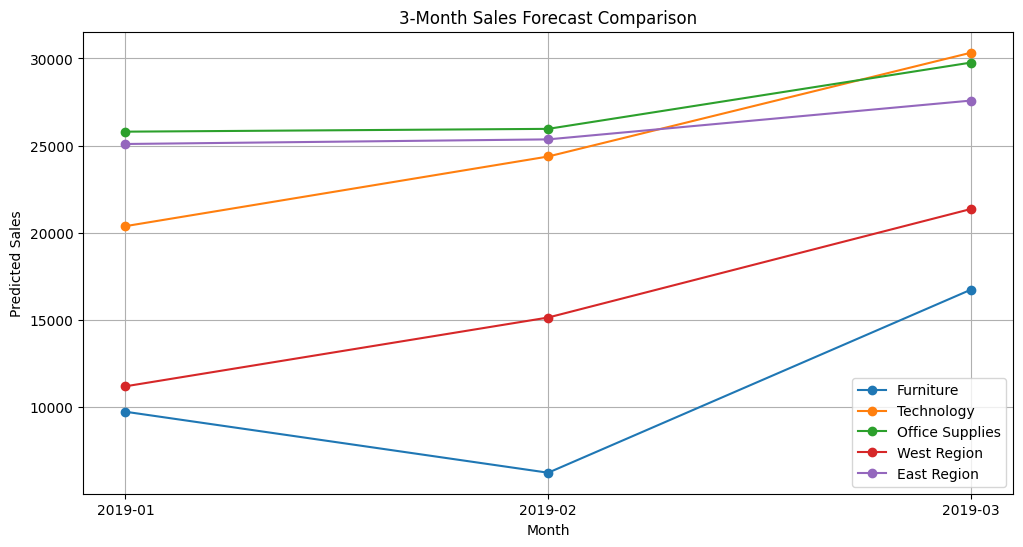

In [144]:
plt.figure(figsize=(12,6))

plt.plot(forecast_comparison['Month'], forecast_comparison['Furniture'],
         marker='o', label='Furniture')

plt.plot(forecast_comparison['Month'], forecast_comparison['Technology'],
         marker='o', label='Technology')

plt.plot(forecast_comparison['Month'], forecast_comparison['Office Supplies'],
         marker='o', label='Office Supplies')

plt.plot(forecast_comparison['Month'], forecast_comparison['West'],
         marker='o', label='West Region')

plt.plot(forecast_comparison['Month'], forecast_comparison['East'],
         marker='o', label='East Region')

plt.title('3-Month Sales Forecast Comparison')
plt.xlabel('Month')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True)
plt.savefig("forecast.png", dpi=300, bbox_inches="tight")
plt.show()

Based on the XGBoost forecasting model, Technology category is expected to show the strongest growth over the next three months, increasing from approximately 20,371 in January to 30,329 in March.

Among the regions, the East region is forecast to have the highest sales, increasing from approximately 25,088 in January to 27,581 in March.

Therefore, the Technology category and East region appear to have the strongest upcoming growth according to the forecasting model.

# Task 5 — Anomaly Detection in Sales Data


In [145]:
weekly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales']
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [146]:
print(weekly_sales.shape)
weekly_sales.tail()

(209, 2)


,Order Date,Sales
204,2018-12-02,35998.9000
205,2018-12-09,21537.2410
206,2018-12-16,11542.8340
207,2018-12-23,19457.0680
208,2018-12-30,15210.8858


In [147]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iso_model = IsolationForest(
    contamination=0.05,   # Around 5% anomalies
    random_state=42
)

weekly_sales['Anomaly'] = iso_model.fit_predict(weekly_sales[['Sales']])

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


In [148]:
weekly_sales['Anomaly_Label'] = weekly_sales['Anomaly'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

weekly_sales.head()

,Order Date,Sales,Anomaly,Anomaly_Label
0,2015-01-04,304.508,-1,Anomaly
1,2015-01-11,4619.108,1,Normal
2,2015-01-18,4130.533,1,Normal
3,2015-01-25,3092.544,1,Normal
4,2015-02-01,2527.914,1,Normal


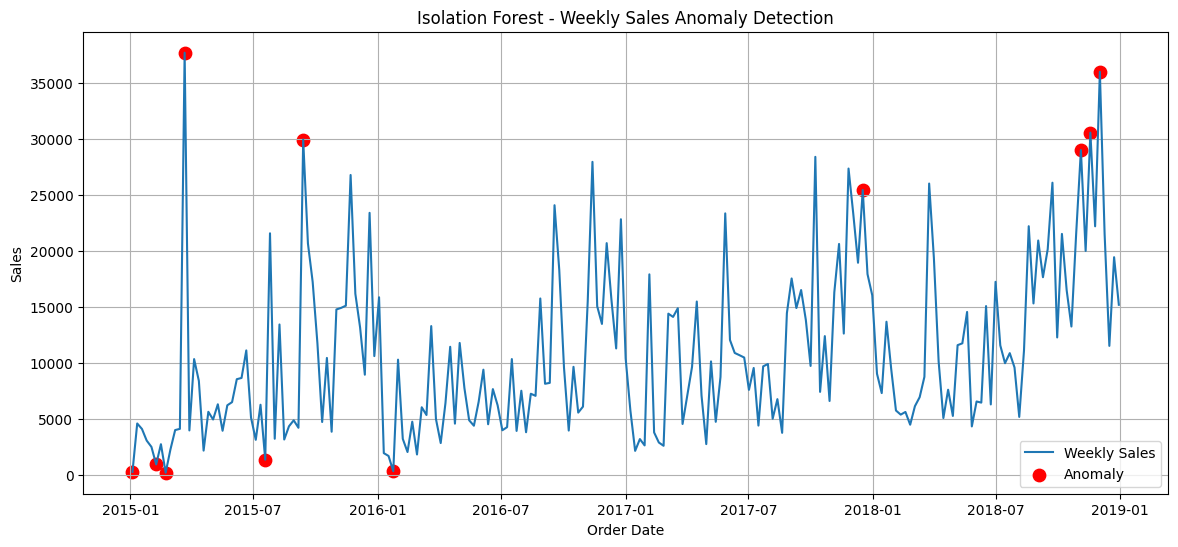

In [149]:
plt.figure(figsize=(14,6))

# Normal Sales Line
plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

# Highlight Anomalies
anomalies = weekly_sales[weekly_sales['Anomaly'] == -1]

plt.scatter(
    anomalies['Order Date'],
    anomalies['Sales'],
    color='red',
    label='Anomaly',
    s=80
)

plt.title('Isolation Forest - Weekly Sales Anomaly Detection')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.show()

In [150]:
isolation_anomalies = weekly_sales[weekly_sales['Anomaly'] == -1]

isolation_anomalies[['Order Date', 'Sales']]


,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


### Interpretation of Isolation Forest Anomalies

The Isolation Forest model detected 11 unusual sales weeks in the dataset.

- **Low sales anomalies (January 2015, February 2015, and January 2016):** These weeks recorded unusually low sales, which may be due to lower customer demand after the holiday season, fewer orders, or normal seasonal fluctuations.

- **High sales anomalies (March 2015 and September 2015):** These weeks showed a significant increase in sales, which could be the result of promotional campaigns, bulk customer purchases, or special business events.

- **Holiday season anomalies (December 2017, November 2018, and December 2018):** These weeks had exceptionally high sales, which are likely associated with festive shopping, year-end discounts, Black Friday offers, and holiday promotions.

Overall, the detected anomalies indicate that most unusual sales patterns are linked to seasonal demand, promotional activities, and festive shopping periods, while low sales weeks are mainly associated with periods of reduced customer demand.

In [151]:
weekly_sales['Rolling_Mean'] = (
    weekly_sales['Sales']
    .rolling(window=4)
    .mean()
    .shift(1)
)

weekly_sales['Rolling_STD'] = (
    weekly_sales['Sales']
    .rolling(window=4)
    .std()
    .shift(1)
)

weekly_sales['Z_Score'] = (
    (weekly_sales['Sales'] - weekly_sales['Rolling_Mean']) /
    weekly_sales['Rolling_STD']
)

weekly_sales['Z_Anomaly'] = weekly_sales['Z_Score'].abs() > 2

In [152]:
zscore_anomalies = weekly_sales[weekly_sales['Z_Anomaly']]

zscore_anomalies[['Order Date', 'Sales', 'Z_Score']]

,Order Date,Sales,Z_Score
5,2015-02-08,968.5340,-2.752352
7,2015-02-22,224.9120,-2.242690
9,2015-03-08,4030.7280,2.102431
11,2015-03-22,37703.6650,19.060372
22,2015-06-07,8569.9480,2.327130
24,2015-06-21,11139.4446,2.792849
26,2015-07-05,3158.4000,-2.120808
29,2015-07-26,21590.0800,8.119383
36,2015-09-13,29959.1370,35.956949
46,2015-11-22,26793.6235,2.638264


In [153]:
weekly_sales['Z_Score'].describe()

count    205.000000
mean       0.451584
std        3.442662
min       -5.986298
25%       -0.812021
50%       -0.234949
75%        0.937588
max       35.956949
Name: Z_Score, dtype: float64

In [154]:
weekly_sales['Z_Score'].max(), weekly_sales['Z_Score'].min()

(np.float64(35.956949063587004), np.float64(-5.986297620725427))

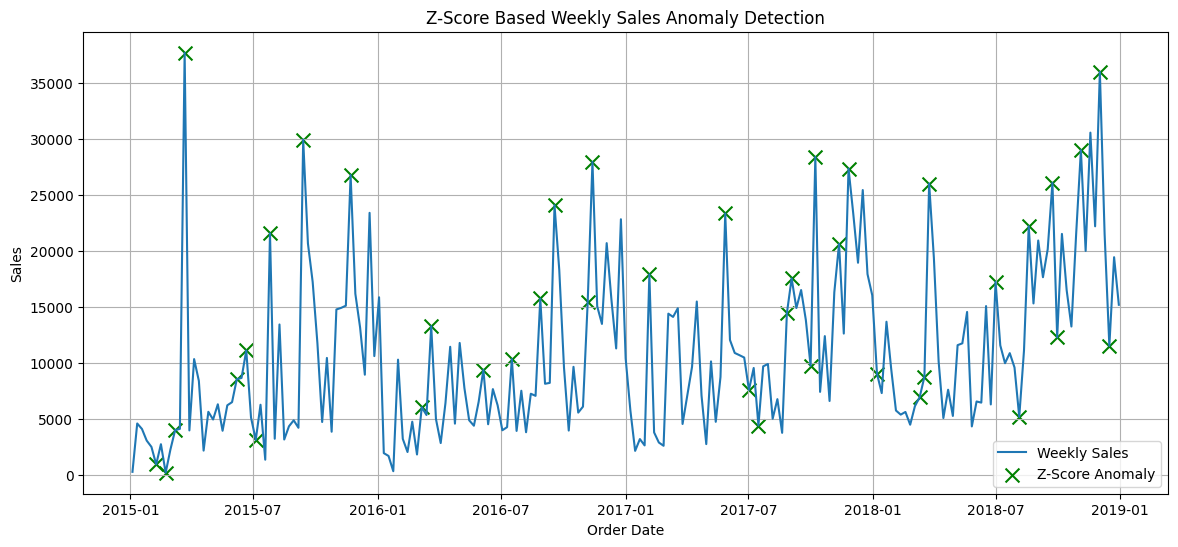

In [155]:
plt.figure(figsize=(14,6))

# Weekly Sales Line
plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

# Highlight Z-Score Anomalies
zscore_anomalies = weekly_sales[weekly_sales['Z_Anomaly']]

plt.scatter(
    zscore_anomalies['Order Date'],
    zscore_anomalies['Sales'],
    color='green',
    marker='x',
    s=100,
    label='Z-Score Anomaly'
)

plt.title('Z-Score Based Weekly Sales Anomaly Detection')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.savefig("anomaly.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation of Z-Score Anomalies

The Z-Score method detected sales weeks that were significantly higher or lower than the rolling average. High positive Z-Scores indicate unusually high sales, which may be caused by festive seasons, promotional offers, or bulk customer orders. Negative Z-Scores represent unusually low sales, which may occur due to reduced customer demand or seasonal slowdowns. Compared to Isolation Forest, the Z-Score method identified more anomalies because it flags every observation that deviates beyond the defined statistical threshold.

In [156]:
comparison = weekly_sales[['Order Date', 'Sales']].copy()

comparison['Isolation Forest'] = weekly_sales['Anomaly'] == -1
comparison['Z-Score'] = weekly_sales['Z_Anomaly']

comparison[
    (comparison['Isolation Forest']) |
    (comparison['Z-Score'])
].reset_index(drop=True)

,Order Date,Sales,Isolation Forest,Z-Score
0,2015-01-04,304.5080,True,False
1,2015-02-08,968.5340,True,True
2,2015-02-22,224.9120,True,True
3,2015-03-08,4030.7280,False,True
4,2015-03-22,37703.6650,True,True
5,2015-06-07,8569.9480,False,True
6,2015-06-21,11139.4446,False,True
7,2015-07-05,3158.4000,False,True
8,2015-07-19,1387.6860,True,False
9,2015-07-26,21590.0800,False,True


### Comparison of Isolation Forest and Z-Score

Both methods were used to detect unusual sales patterns in the weekly sales data.

Isolation Forest identified anomalies by learning the overall data distribution, making it effective in detecting both high and low sales weeks. Z-Score detected anomalies based on statistical deviation from the rolling mean.

Some anomalies were detected by both methods, while others were identified by only one method. This difference occurs because Isolation Forest is a machine learning algorithm, whereas Z-Score is a statistical approach.

Overall, Isolation Forest provides a more flexible and robust method for anomaly detection, especially when the sales data contains complex patterns.

# Task 6 — Product Demand Segmentation using Clustering


In this task, product sub-categories are grouped based on their sales performance and demand characteristics. Features such as total sales, sales growth rate, sales volatility, and average order value are used to identify similar demand patterns. K-Means clustering is then applied to segment the products into meaningful business groups.

In [157]:
# Monthly sales by Sub-Category

monthly_sales = (
    df.groupby([
        'Sub-Category',
        pd.Grouper(key='Order Date', freq='ME')
    ])['Sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [158]:
# Create product level features

product_features = monthly_sales.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Monthly_Sales=('Sales', 'mean'),
    Sales_Volatility=('Sales', 'std')
).reset_index()

product_features.head()

,Sub-Category,Total_Sales,Avg_Monthly_Sales,Sales_Volatility
0,Accessories,164186.7000,3420.556250,2579.994809
1,Appliances,104618.4030,2179.550062,1821.621539
2,Art,26705.4100,556.362708,330.488343
3,Binders,200028.7850,4167.266354,3848.223648
4,Bookcases,113813.1987,2474.199972,2220.405080


In [159]:
# Calculate yearly sales by Sub-Category

yearly_sales = (
    df.groupby([
        'Sub-Category',
        'Year'
    ])['Sales']
    .sum()
    .reset_index()
)

# Calculate Year-over-Year Growth

yearly_sales['Growth_Rate'] = (
    yearly_sales.groupby('Sub-Category')['Sales']
    .pct_change()
)

# Average Growth Rate for each Sub-Category

growth_rate = (
    yearly_sales.groupby('Sub-Category')['Growth_Rate']
    .mean()
    .reset_index()
)

In [160]:
# Average Order Value

avg_order = (
    df.groupby('Sub-Category')['Sales']
    .mean()
    .reset_index()
    .rename(columns={'Sales':'Average_Order_Value'})
)

In [161]:
# Merge all features

product_features = product_features.merge(
    growth_rate,
    on='Sub-Category',
    how='left'
)

product_features = product_features.merge(
    avg_order,
    on='Sub-Category',
    how='left'
)

# Fill missing growth values

product_features['Growth_Rate'] = product_features['Growth_Rate'].fillna(0)

product_features.head()

,Sub-Category,Total_Sales,Avg_Monthly_Sales,Sales_Volatility,Growth_Rate,Average_Order_Value
0,Accessories,164186.7000,3420.556250,2579.994809,0.376381,217.178175
1,Appliances,104618.4030,2179.550062,1821.621539,0.399276,227.926804
2,Art,26705.4100,556.362708,330.488343,0.166056,34.019631
3,Binders,200028.7850,4167.266354,3848.223648,0.218736,134.067550
4,Bookcases,113813.1987,2474.199972,2220.405080,0.238065,503.598224


In [162]:
from sklearn.preprocessing import StandardScaler

# Features for clustering
X = product_features[
    [
        'Total_Sales',
        'Avg_Monthly_Sales',
        'Sales_Volatility',
        'Growth_Rate',
        'Average_Order_Value'
    ]
]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the scaled data
X_scaled[:5]

array([[ 0.31598599,  0.23203938,  0.08508503,  0.11450548, -0.36354857],
       [-0.28817617, -0.35116226, -0.34706199,  0.16628324, -0.34520236],
       [-1.07839653, -1.1139671 , -1.19676068, -0.36114889, -0.67617125],
       [ 0.67950874,  0.58295025,  0.80776519, -0.24201087, -0.50540527],
       [-0.19491939, -0.21269372, -0.11982149, -0.19829775,  0.12532518]])

### Elbow Method

The Elbow Method is used to determine the optimal number of clusters for K-Means. It calculates the Within-Cluster Sum of Squares (WCSS) for different values of k. The point where the decrease in WCSS starts slowing down is called the "elbow" and is selected as the optimal number of clusters.

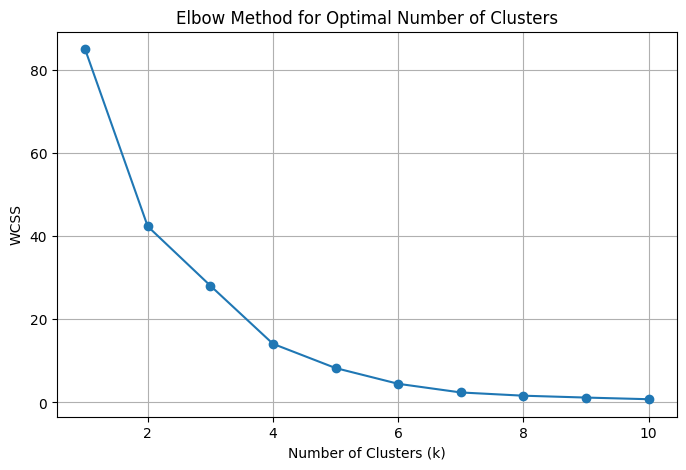

In [163]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS for different values of k
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.savefig("cluster.png", dpi=300, bbox_inches="tight")
plt.show()

In [164]:
from sklearn.cluster import KMeans

# Apply K-Means with 4 clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_features['Cluster'] = kmeans.fit_predict(X_scaled)

# Display results
product_features.head()

,Sub-Category,Total_Sales,Avg_Monthly_Sales,Sales_Volatility,Growth_Rate,Average_Order_Value,Cluster
0,Accessories,164186.7000,3420.556250,2579.994809,0.376381,217.178175,2
1,Appliances,104618.4030,2179.550062,1821.621539,0.399276,227.926804,1
2,Art,26705.4100,556.362708,330.488343,0.166056,34.019631,1
3,Binders,200028.7850,4167.266354,3848.223648,0.218736,134.067550,2
4,Bookcases,113813.1987,2474.199972,2220.405080,0.238065,503.598224,1


### PCA Visualization

Since the dataset contains multiple features, PCA (Principal Component Analysis) is used to reduce them into two dimensions. This makes it easier to visualize the clusters formed by the K-Means algorithm.

In [165]:
from sklearn.decomposition import PCA

# Reduce features to 2 dimensions
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = product_features.copy()

pca_df["PCA1"] = pca_features[:, 0]
pca_df["PCA2"] = pca_features[:, 1]

pca_df.head()

,Sub-Category,Total_Sales,Avg_Monthly_Sales,Sales_Volatility,Growth_Rate,Average_Order_Value,Cluster,PCA1,PCA2
0,Accessories,164186.7000,3420.556250,2579.994809,0.376381,217.178175,2,0.185351,-0.181037
1,Appliances,104618.4030,2179.550062,1821.621539,0.399276,227.926804,1,-0.666455,0.063670
2,Art,26705.4100,556.362708,330.488343,0.166056,34.019631,1,-2.050306,-0.308402
3,Binders,200028.7850,4167.266354,3848.223648,0.218736,134.067550,2,0.911808,-0.570888
4,Bookcases,113813.1987,2474.199972,2220.405080,0.238065,503.598224,1,-0.222208,-0.036078


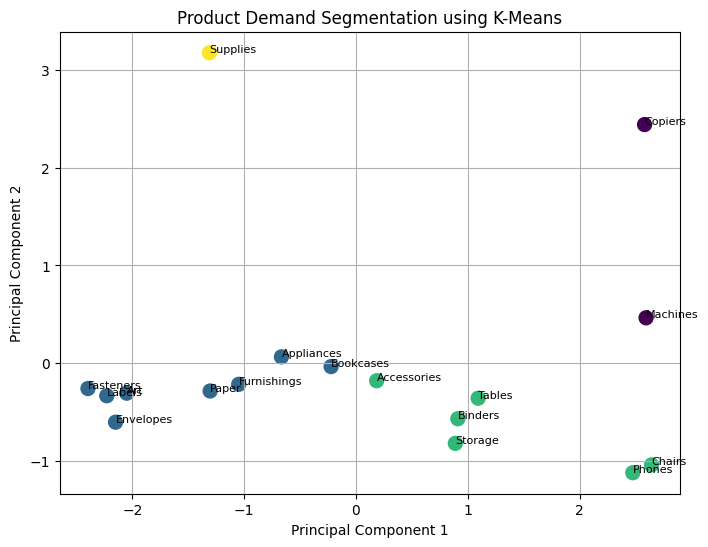

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PCA1"],
    pca_df["PCA2"],
    c=pca_df["Cluster"],
    s=100
)

# Show Sub-Category names
for i in range(len(pca_df)):
    plt.text(
        pca_df["PCA1"][i],
        pca_df["PCA2"][i],
        pca_df["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

In [167]:
cluster_summary = product_features.groupby("Cluster").agg({
    "Total_Sales": "mean",
    "Growth_Rate": "mean",
    "Sales_Volatility": "mean",
    "Average_Order_Value": "mean",
    "Sub-Category": "count"
})

cluster_summary

,Total_Sales,Growth_Rate,Sales_Volatility,Average_Order_Value,Sub-Category
Cluster,,,,,
0,167743.362500,0.463389,5552.164569,1930.716763,2
1,55331.883212,0.199589,907.223743,129.054568,8
2,239495.780667,0.180965,3489.056075,361.131228,6
3,46420.308000,1.928448,2025.094139,252.284283,1


### Cluster Interpretation and Business Recommendations

The K-Means algorithm grouped the product sub-categories into four clusters:

- **Cluster 0 – Premium Products:** High average order value and fluctuating demand. Maintain sufficient inventory and monitor demand regularly.

- **Cluster 1 – Low Demand Products:** Lower sales and relatively stable demand. Keep limited inventory to avoid overstocking.

- **Cluster 2 – High Volume Products:** Highest total sales with consistent demand. Ensure regular stock replenishment to prevent stock-outs.

- **Cluster 3 – Fast Growing Product:** Highest sales growth rate. Increase inventory gradually and monitor future demand closely.